## ProcessEmbeddings+FindMedianEmbeddingPerBuurt
This script:
- Loads sample points and their CLIP embeddings from the H5 data store
- Spatially joins points to CBS **buurten** (the Amsterdam analysis unit)
- Expands so that each image (and associated embedding) is its own row, skipping missing images and NaN embeddings
- Removes some outlying images (_optional, currently disabled_)
- Saves the expanded results for use in future scripts
- Finds the mean and median embedding per buurt, and saves pickle files containing this information

The join key is `buurtcode` (`BU0363....`), defined centrally as `JOIN_KEY` in `directory_filepaths.py`.

### Dependencies
**Prerequisites:** Script 2 (H5 store must contain CLIP embeddings).

**Inputs:**
- `street_data.h5` (via `h5_filename`) - reads `point_id`, `latitude`, `longitude`, `embeddings_clip`, `images_present`, `image_paths`
- Amsterdam buurt boundaries (CBS WijkBuurtkaart 2024 via PDOK), fetched/cached by `amsterdam_data.get_amsterdam_buurten()` to `boundaries_file`

**Outputs:**
- `data/processed/one_row_per_image_cleaned.pkl` - expanded GeoDataFrame (one row per valid image)
- `data/processed/per_buurt_embedding_summaries/mean_embedding.pkl` - per-buurt mean embeddings
- `data/processed/per_buurt_embedding_summaries/median_embedding.pkl` - per-buurt median embeddings

**Used by:** Scripts 4, 5

In [1]:
import numpy as np
import pandas as pd
import h5py
import os
from shapely.geometry import Point
import geopandas as gpd
import matplotlib.pyplot as plt

In [2]:
from directory_filepaths import *
from amsterdam_data import get_amsterdam_buurten

### Get spatial data
Amsterdam municipality buurten (land only). Reprojected to EPSG:4326 for the point spatial join,
the point spatial join is performed in geographic coordinates (lat/lon).

In [3]:
ams_buurten = get_amsterdam_buurten()                 # EPSG:28992 (PROJECTED_CRS)
# Keep only the join key and name for the join (avoid carrying CBS demographic columns)
ams_buurten = ams_buurten[[JOIN_KEY, 'buurtnaam', 'geometry']].copy()
ams_buurten = ams_buurten.to_crs(epsg=4326)
print(f"Amsterdam buurten: {len(ams_buurten)}")

Amsterdam buurten: 839


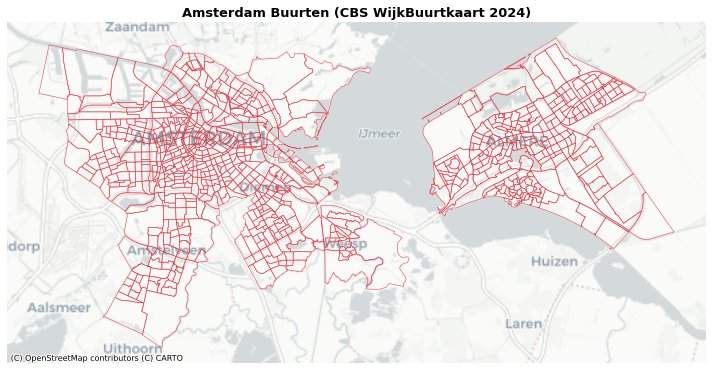

In [4]:
import contextily as ctx

fig, ax = plt.subplots(figsize=(10, 10))
ams_buurten.to_crs(epsg=3857).plot(
    ax=ax, facecolor="none", edgecolor="#e63946", linewidth=0.6, alpha=0.85
)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom="auto")
ax.set_axis_off()
ax.set_title("Amsterdam Buurten (CBS WijkBuurtkaart 2024)", fontsize=13, fontweight="bold")
plt.tight_layout()
show_jpeg()

> **Note — the gap in coverage is expected, not a bug.** The Amsterdam municipality is
> *non-contiguous*: a connected-components check of the 517 buurten finds the main body (445
> buurten) plus a detached south-eastern cluster (70 buurten) made up of **Amsterdam-Zuidoost**
> (Bijlmer) together with **Weesp** and **Driemond** (a separate town that merged into the
> municipality in 2022), and two IJburg islands. The empty land between them belongs to other
> municipalities (Diemen, Ouder-Amstel), which are correctly excluded by the `gemeentecode`
> filter in `get_amsterdam_buurten()`. We keep the whole municipality: it matches the SES-WOA
> target (also fetched for all of `BU0363…`), and any buurt without panorama coverage simply
> drops out of the spatial join downstream.

### Get embeddings (four per location)

In [5]:
with h5py.File(h5_filename, "r") as f:
    point_ids = f["point_id"][:]
    latitudes = f["latitude"][:]
    longitudes = f["longitude"][:]
    embeddings = f["embeddings_clip"][:]        # (N, 4, 512)
    images_present = f["images_present"][:]     # (N, 4)
    image_paths = f["image_paths"][:]           # (N, 4)

print(f"Loaded {len(point_ids)} points from H5 store")

Loaded 50048 points from H5 store


### Join image embedding points to Amsterdam buurten

In [6]:
points_df = pd.DataFrame({
    "point_id": point_ids,
    "latitude": latitudes,
    "longitude": longitudes,
})

point_coords = [Point(lon, lat) for lon, lat in zip(longitudes, latitudes)]
points_gdf = gpd.GeoDataFrame(points_df, geometry=point_coords, crs="EPSG:4326")

# Perform spatial join to get the buurt for each point
points_labels_gdf = gpd.sjoin(points_gdf, ams_buurten, how='inner', predicate='within')

if 'index_right' in points_labels_gdf.columns:
    points_labels_gdf = points_labels_gdf.drop(columns=['index_right'])

print(f"Points after spatial join: {len(points_labels_gdf)} / {len(points_df)}"
      f" (some points may lie outside the buurt polygons and were dropped)")

Points after spatial join: 50048 / 50048 (some points may lie outside the buurt polygons and were dropped)


Check spatial join results by plotting points and buurt boundaries together

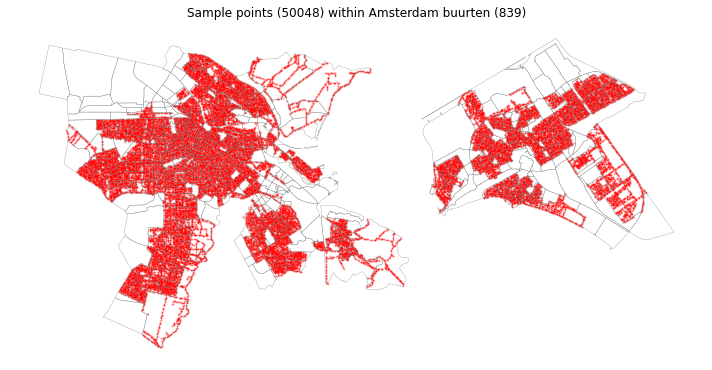

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ams_buurten.boundary.plot(ax=ax, linewidth=0.3, color="grey")
points_labels_gdf.plot(ax=ax, markersize=1, color="red", alpha=0.3)
ax.set_title(f"Sample points ({len(points_labels_gdf)}) within Amsterdam buurten ({len(ams_buurten)})")
ax.set_axis_off()
plt.tight_layout()
plt.show()

# Expand dataframe so there is one row per image

In [8]:
expanded_rows = []

for idx, row in points_labels_gdf.iterrows():
    # idx is the original index into the H5 arrays
    for j in range(4):
        if not images_present[idx, j]:
            continue
        emb = embeddings[idx, j, :]  # (512,)
        if np.all(np.isnan(emb)):
            continue

        new_row = row.to_dict()
        new_row['embedding'] = emb
        new_row['image_path'] = image_paths[idx, j].decode("ascii") if isinstance(image_paths[idx, j], bytes) else str(image_paths[idx, j])
        expanded_rows.append(new_row)

expanded_gdf = pd.DataFrame(expanded_rows)
print(f"Points with buurt: {len(points_labels_gdf)}, Expanded rows (one per image): {len(expanded_gdf)}")

Points with buurt: 50048, Expanded rows (one per image): 200192


In [9]:
expanded_gdf

,point_id,latitude,longitude,geometry,buurtcode,buurtnaam,embedding,image_path
0,0,52.338331,5.135787,POINT (5.1357867600834 52.3383313335052),BU00346602,Duin Zuid,"[-0.012054443, 0.01197052, 0.03161621, 0.02873...",../raw/panorama_images/TMX7316010203-002266_pa...
1,0,52.338331,5.135787,POINT (5.1357867600834 52.3383313335052),BU00346602,Duin Zuid,"[0.013656616, 0.002614975, -0.0056610107, -0.0...",../raw/panorama_images/TMX7316010203-002266_pa...
2,0,52.338331,5.135787,POINT (5.1357867600834 52.3383313335052),BU00346602,Duin Zuid,"[-0.031982422, 0.018936157, -0.019088745, 0.00...",../raw/panorama_images/TMX7316010203-002266_pa...
3,0,52.338331,5.135787,POINT (5.1357867600834 52.3383313335052),BU00346602,Duin Zuid,"[-0.06561279, 0.034851074, -0.017913818, -0.01...",../raw/panorama_images/TMX7316010203-002266_pa...
4,1,52.338017,5.136135,POINT (5.13613513993084 52.3380172367688),BU00346602,Duin Zuid,"[-0.028701782, 0.01058197, -0.006225586, -0.00...",../raw/panorama_images/TMX7316010203-002266_pa...
...,...,...,...,...,...,...,...,...
200187,50046,52.345222,4.978260,POINT (4.97826022008138 52.3452218426547),BU03840105,Vlindertuin,"[-0.029342651, -0.0031089783, -0.0418396, 0.01...",../raw/panorama_images/TMX7316060226-000019_pa...
200188,50047,52.345339,4.978033,POINT (4.97803298647454 52.3453393170714),BU03840104,Scheepskwartier,"[-0.052246094, 0.028701782, -0.013313293, 0.01...",../raw/panorama_images/TMX7316060226-000019_pa...
200189,50047,52.345339,4.978033,POINT (4.97803298647454 52.3453393170714),BU03840104,Scheepskwartier,"[-0.022521973, -0.005554199, -0.027404785, 0.0...",../raw/panorama_images/TMX7316060226-000019_pa...
200190,50047,52.345339,4.978033,POINT (4.97803298647454 52.3453393170714),BU03840104,Scheepskwartier,"[-0.02230835, 0.022781372, -0.002948761, 0.037...",../raw/panorama_images/TMX7316060226-000019_pa...


# Remove inside cars and inside buildings images
Decided this stage wasn't necessary, leaving code for reference

In [10]:
# # Example wrapper if you have a dataframe
# embeddings = np.vstack(expanded_gdf["embedding"].values)   # shape (N, 512)
#              # string labels
# reducer = umap.UMAP(
#     n_neighbors=30, 
#     min_dist=0.1, 
#     metric='cosine',   # recommended for CLIP embeddings
#     random_state=42)

# emb_2d = reducer.fit_transform(embeddings)  # shape (N, 2)

# expanded_gdf['umap_x'] = emb_2d[:, 0]
# expanded_gdf['umap_y'] = emb_2d[:, 1]

## Save results

In [11]:
one_row_per_image_path = os.path.join(data_dir, "one_row_per_image_cleaned.pkl")
os.makedirs(os.path.dirname(one_row_per_image_path), exist_ok=True)
expanded_gdf.to_pickle(one_row_per_image_path)

### Find mean and median embedding per buurt and pickle them

In [12]:
# Keep only what we need for aggregation: the buurt code and the embedding
agg_df = expanded_gdf[[JOIN_KEY, 'embedding']].copy()

In [13]:
def mean_embed(series):
    return np.mean(np.stack(series.values), axis=0)

def median_embed(series):
    return np.median(np.stack(series.values), axis=0)

emb_cat_mean = agg_df.groupby(JOIN_KEY)["embedding"].apply(mean_embed).reset_index()
emb_cat_mean.rename(columns={"embedding": "mean_embedding"}, inplace=True)

emb_cat_median = agg_df.groupby(JOIN_KEY)["embedding"].apply(median_embed).reset_index()
emb_cat_median.rename(columns={"embedding": "median_embedding"}, inplace=True)

In [14]:
summary_dir = os.path.join(data_dir, "per_buurt_embedding_summaries")
os.makedirs(summary_dir, exist_ok=True)

emb_cat_mean.to_pickle(os.path.join(summary_dir, "mean_embedding.pkl"))
emb_cat_median.to_pickle(os.path.join(summary_dir, "median_embedding.pkl"))

### Sanity-check map — aggregate buurt embeddings as RGB

A buurt-level counterpart to the per-point RGB map in notebook 2. We colour each buurt by its
**median** street-level embedding, pushed through the **same** cached PCA→RGB model that notebook 2
fit on the per-crop embeddings — so a buurt's colour here is directly comparable to the point colours
there. As before, we are not after a meaning for each axis: the test is **spatial coherence**, with
neighbouring buurten of similar character (centre, water frontage, post-war estates, green edges)
forming smooth patches rather than salt-and-pepper noise.

If notebook 2's cached model is missing, the model is refit on the buurt medians as a fallback (the
colours then stand alone rather than matching notebook 2).

In [15]:
from embedding_rgb import load_embedding_rgb, fit_embedding_rgb, embeddings_to_rgb

# Stack the per-buurt median embeddings (one 512-d vector per buurt)
buurt_emb = np.stack(emb_cat_median["median_embedding"].values)   # (n_buurten, 512)

# Reuse the SAME PCA->RGB colour model that notebook 2 fit on the per-crop
# embeddings, so a buurt's colour here is directly comparable to the point colours
# there. Fall back to fitting on the buurt medians if the cache is absent (e.g.
# notebook 2 has not been run in this environment).
try:
    model = load_embedding_rgb(embedding_rgb_pca_file)
    src = "cached colour model from notebook 2"
except (FileNotFoundError, OSError):
    model = fit_embedding_rgb(buurt_emb)
    src = "model freshly fit on buurt medians (notebook 2 cache not found)"

buurt_rgb = embeddings_to_rgb(model, buurt_emb)   # (n_buurten, 3) in [0, 1]

evr = model["explained_variance_ratio"]
print(f"Coloured {len(emb_cat_median)} buurten using the {src}")
print(f"Explained variance  R: {evr[0]:.1%}  G: {evr[1]:.1%}  B: {evr[2]:.1%}  (total {evr.sum():.1%})")

Coloured 641 buurten using the cached colour model from notebook 2
Explained variance  R: 13.6%  G: 8.2%  B: 5.7%  (total 27.4%)


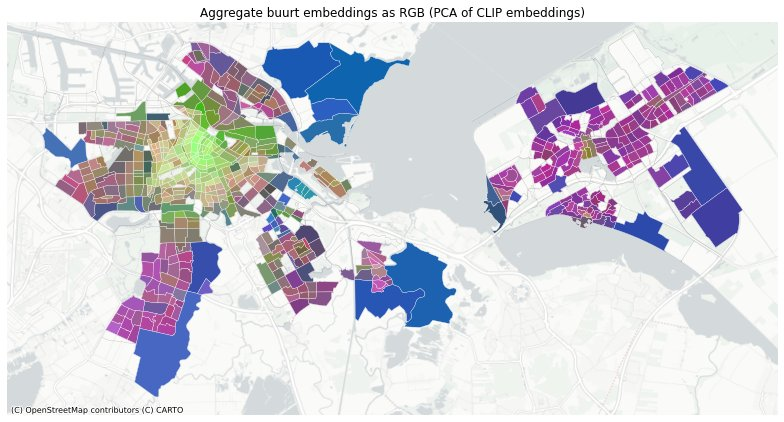

In [16]:
# Attach the colours to the buurt geometries and reproject to Web Mercator (the
# CRS of the contextily basemap tiles). Only buurten with imagery are coloured.
buurt_colours = emb_cat_median[[JOIN_KEY]].copy()
buurt_colours[["r", "g", "b"]] = buurt_rgb
buurt_map = ams_buurten.merge(buurt_colours, on=JOIN_KEY, how="inner").to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(11, 11))

# Faint outlines of *all* buurten for orientation (including any without coverage)
ams_buurten.to_crs(epsg=3857).boundary.plot(
    ax=ax, color="#000000", linewidth=0.3, alpha=0.15, zorder=2)

buurt_map.plot(ax=ax, color=buurt_map[["r", "g", "b"]].to_numpy(),
               edgecolor="white", linewidth=0.3, zorder=3)

# Zoom to the coloured buurten (a dev sample covers only part of the municipality)
xmin, ymin, xmax, ymax = buurt_map.total_bounds
mx = max((xmax - xmin) * 0.05, 200)
my = max((ymax - ymin) * 0.05, 200)
ax.set_xlim(xmin - mx, xmax + mx)
ax.set_ylim(ymin - my, ymax + my)

ctx.add_basemap(ax, source=ctx.providers.CartoDB.PositronNoLabels, crs="EPSG:3857", zorder=1)
ax.set_axis_off()
ax.set_title("Aggregate buurt embeddings as RGB (PCA of CLIP embeddings)", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join("../", "outputs", "3-embeddings-buurt-map.png"), dpi=128)
show_jpeg()